In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [36]:

# Create a list to hold all the data
data = []

# Parse Llama-2 7B data
model_name = "Llama-2 7B"
bits_data = [
    [3, 5.99, 74.66, 39.76, 76.88, 67.88, 55.16, 62.87],
    [2, 7.87, 74.05, 48.79, 61.64, 33.02, 67.09, 56.92],
    [1, 4082.93, 52.45, 25.88, 51.78, 22.44, 26.26, 35.76]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Parse Llama-3 3B data
model_name = "Llama-3 3B"
bits_data = [
    [3, 11.59, 74.92, 49.45, 65.11, 36.69, 69.23, 59.08],
    [2, 16.90, 68.82, 39.76, 54.30, 27.39, 56.44, 47.57],
    [1, 7062.74 , 53.37 , 26.04  , 49.17  , 20.05  , 25.76 , 34.88]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Parse TinyLlama 1.1B data
model_name = "TinyLlama 1.1B"
bits_data = [
    [3, 11.99, 66.21, 39.00, 50.28, 24.32, 41.96, 44.35],
    [2, 23.76, 60.45, 32.35, 52.88, 22.10, 35.90, 40.71],
    [1, 2297.22, 52.83, 25.68, 51.22, 21.50, 26.64, 35.58]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'Model', 'Bits', 'PPL', 'PIQA', 'HellaSwag', 'WinoGrande', 'ARC-c', 'ARC-Easy', 'QA Avg'
])

df

,Model,Bits,PPL,PIQA,HellaSwag,WinoGrande,ARC-c,ARC-Easy,QA Avg
0,Llama-2 7B,3,5.99,74.66,39.76,76.88,67.88,55.16,62.87
1,Llama-2 7B,2,7.87,74.05,48.79,61.64,33.02,67.09,56.92
2,Llama-2 7B,1,4082.93,52.45,25.88,51.78,22.44,26.26,35.76
3,Llama-3 3B,3,11.59,74.92,49.45,65.11,36.69,69.23,59.08
4,Llama-3 3B,2,16.90,68.82,39.76,54.30,27.39,56.44,47.57
5,Llama-3 3B,1,7062.74,53.37,26.04,49.17,20.05,25.76,34.88
6,TinyLlama 1.1B,3,11.99,66.21,39.00,50.28,24.32,41.96,44.35
7,TinyLlama 1.1B,2,23.76,60.45,32.35,52.88,22.10,35.90,40.71
8,TinyLlama 1.1B,1,2297.22,52.83,25.68,51.22,21.50,26.64,35.58


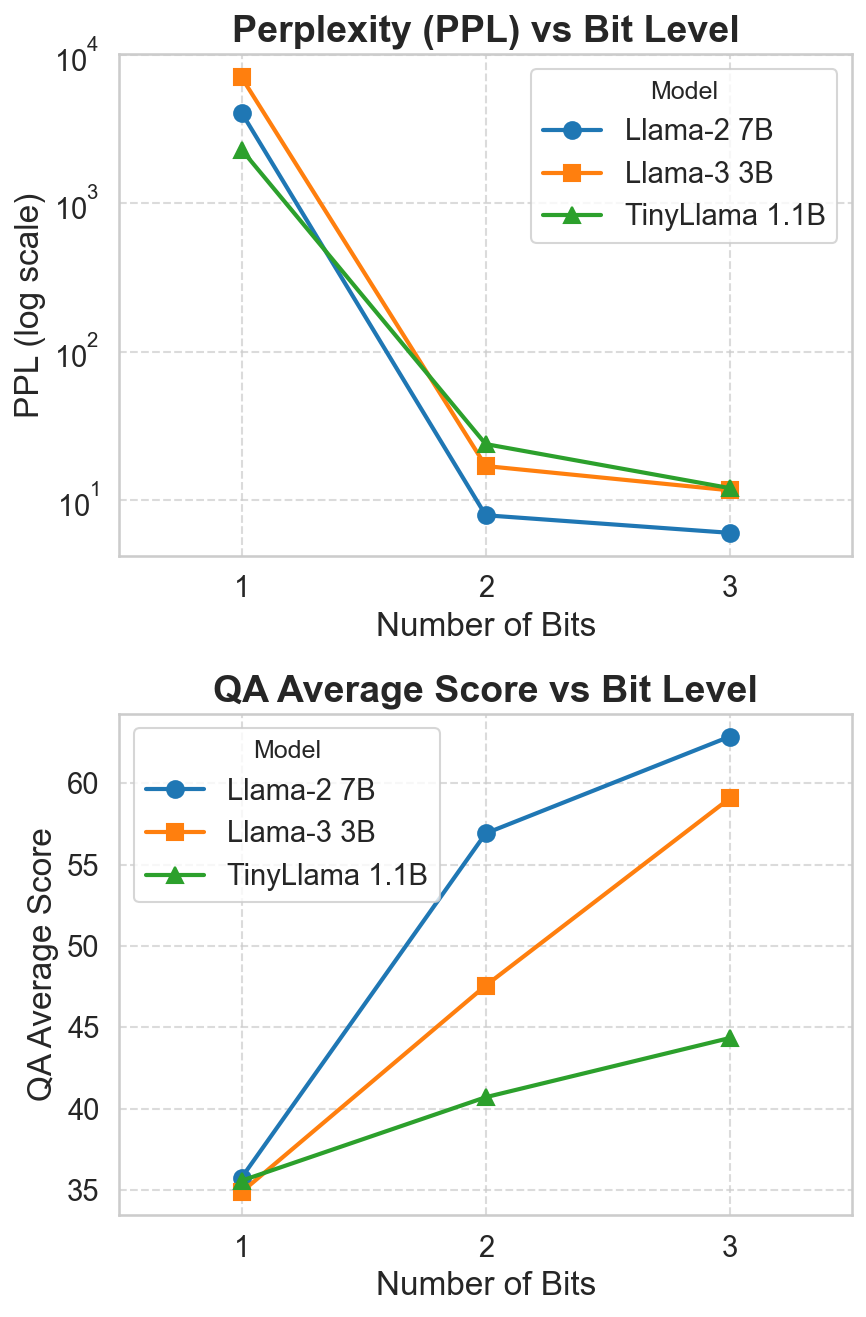

In [37]:
def plot_metric(dataframe, metric_name, use_log_scale=False):
    """
    Plot a metric for all models across different bit levels
    
    Parameters:
    dataframe (pd.DataFrame): DataFrame containing the model performance data
    metric_name (str): Name of the metric column to plot
    use_log_scale (bool): Whether to use log scale for y-axis
    
    Returns:
    matplotlib.figure.Figure: The generated figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Get unique models
    models = dataframe['Model'].unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Default matplotlib colors
    markers = ['o', 's', '^']  # Different markers for each model
    
    # Plot each model as a line
    for i, model in enumerate(models):
        model_data = dataframe[dataframe['Model'] == model]
        # Sort by bits (descending) to ensure correct line plotting
        model_data = model_data.sort_values('Bits', ascending=False)
        ax.plot(model_data['Bits'], model_data[metric_name], 
                marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)
    
    # Set x-axis ticks to integers
    ax.set_xticks([1, 2, 3])
    ax.set_xlim(0.5, 3.5)
    
    # Apply log scale if requested
    if use_log_scale:
        ax.set_yscale('log')
        
    # Add grid, labels and title
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlabel('Number of Bits', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} vs Bit Level Across Models', fontsize=14, fontweight='bold')
    
    # Add legend
    ax.legend(title='Model', loc='best')
    
    # Ensure tight layout
    plt.tight_layout()
    
    return fig

# Set higher DPI for sharper plots
plt.rcParams['figure.dpi'] = 150
# Increase font sizes globally
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

# For the first plot (PPL)
models = df['Model'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# Plot PPL (with log scale) on the first axis
for i, model in enumerate(models):
    model_data = df[df['Model'] == model].sort_values('Bits', ascending=False)
    ax1.plot(model_data['Bits'], model_data['PPL'], 
            marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)

ax1.set_yscale('log')
ax1.set_xticks([1, 2, 3])
ax1.set_xlim(0.5, 3.5)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xlabel('Number of Bits')
ax1.set_ylabel('PPL (log scale)')
ax1.set_title('Perplexity (PPL) vs Bit Level', fontweight='bold')
ax1.legend(title='Model', loc='best')

# Plot QA Avg on the second axis
for i, model in enumerate(models):
    model_data = df[df['Model'] == model].sort_values('Bits', ascending=False)
    ax2.plot(model_data['Bits'], model_data['QA Avg'], 
            marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)

ax2.set_xticks([1, 2, 3])
ax2.set_xlim(0.5, 3.5)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xlabel('Number of Bits')
ax2.set_ylabel('QA Average Score')
ax2.set_title('QA Average Score vs Bit Level', fontweight='bold')
ax2.legend(title='Model', loc='best')

plt.tight_layout()
plt.savefig("plots/benchmark_scaling.pdf", format="pdf", bbox_inches="tight")
plt.show()

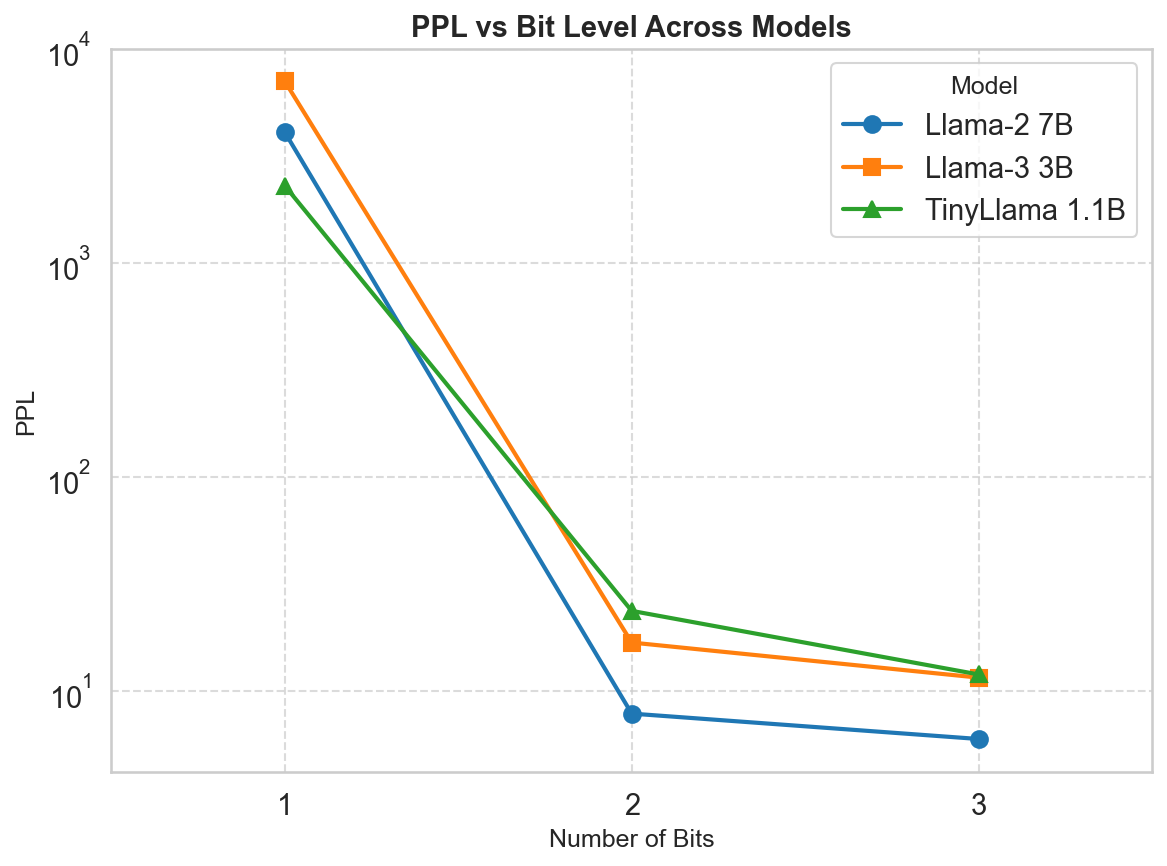

In [38]:
ppl_fig = plot_metric(df, 'PPL', use_log_scale=True)
plt.figure(ppl_fig.number)
plt.show()

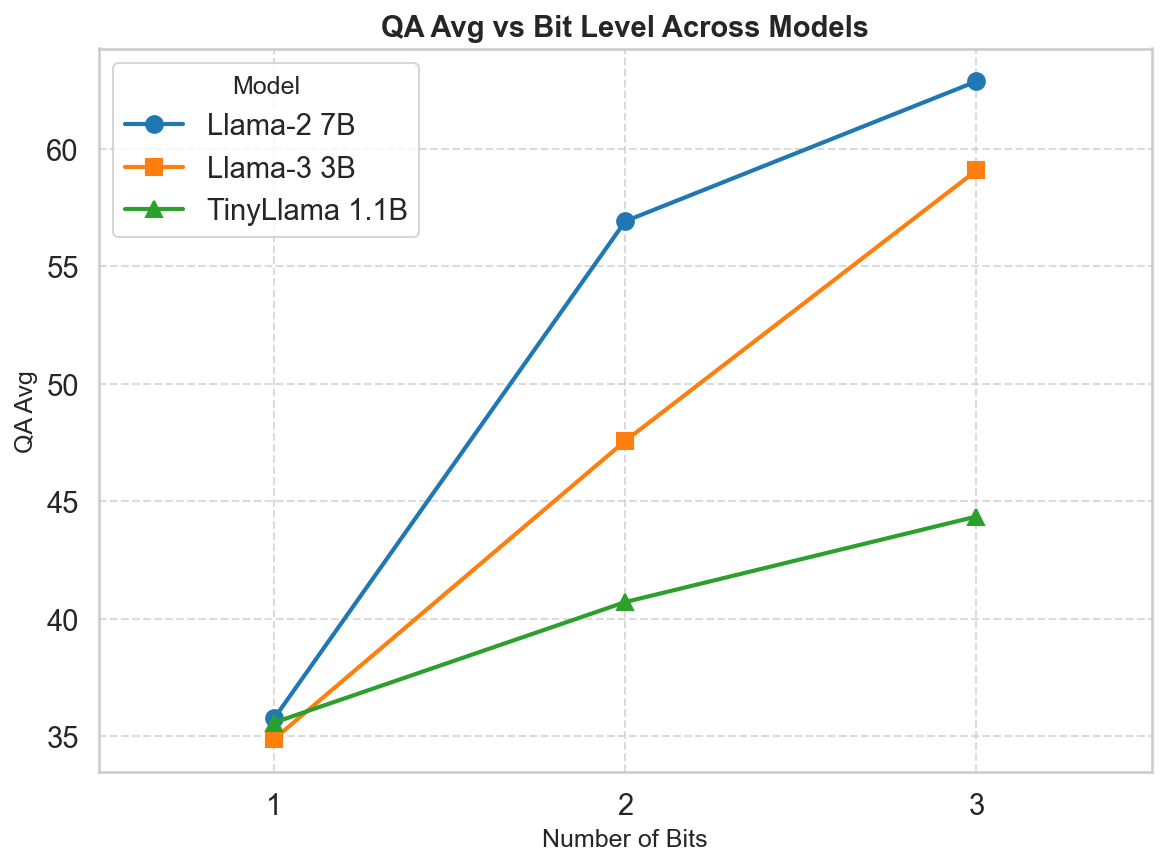

In [39]:
qa_avg_fig = plot_metric(df, 'QA Avg')
plt.figure(qa_avg_fig.number)
plt.show()

In [40]:
# full precision qas

fp_qas = {
    "Llama-2 7B": 64.79, 
    "Llama-3 3B": 60.94,
    "TinyLlama 1.1B": 54.25 
}

In [41]:
df["FP_qa_avg"] = 0. 

for model, qa_avg in fp_qas.items():
    df.loc[df["Model"] == model, "FP_qa_avg"] = qa_avg
df["QA_fp_fraction"] = df["QA Avg"] / df["FP_qa_avg"] 
df

,Model,Bits,PPL,PIQA,HellaSwag,WinoGrande,ARC-c,ARC-Easy,QA Avg,FP_qa_avg,QA_fp_fraction
0,Llama-2 7B,3,5.99,74.66,39.76,76.88,67.88,55.16,62.87,64.79,0.970366
1,Llama-2 7B,2,7.87,74.05,48.79,61.64,33.02,67.09,56.92,64.79,0.878531
2,Llama-2 7B,1,4082.93,52.45,25.88,51.78,22.44,26.26,35.76,64.79,0.551937
3,Llama-3 3B,3,11.59,74.92,49.45,65.11,36.69,69.23,59.08,60.94,0.969478
4,Llama-3 3B,2,16.90,68.82,39.76,54.30,27.39,56.44,47.57,60.94,0.780604
5,Llama-3 3B,1,7062.74,53.37,26.04,49.17,20.05,25.76,34.88,60.94,0.572366
6,TinyLlama 1.1B,3,11.99,66.21,39.00,50.28,24.32,41.96,44.35,54.25,0.817512
7,TinyLlama 1.1B,2,23.76,60.45,32.35,52.88,22.10,35.90,40.71,54.25,0.750415
8,TinyLlama 1.1B,1,2297.22,52.83,25.68,51.22,21.50,26.64,35.58,54.25,0.655853


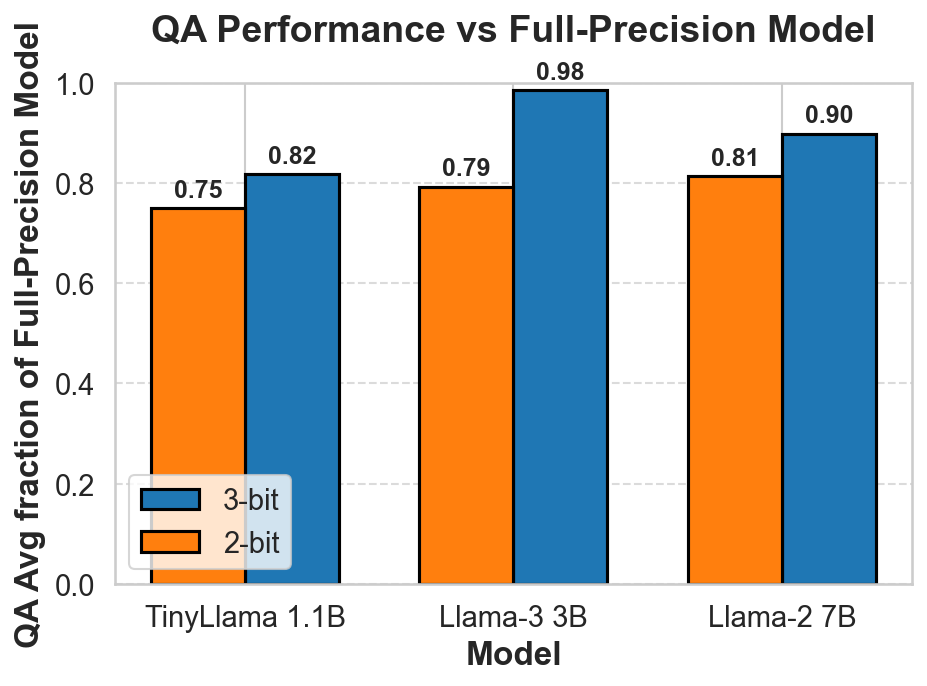

In [23]:
# Filter for only 2 and 3 bit models
filtered_df = df[df['Bits'].isin([2, 3])]

# Create a grouped bar chart
fig, ax = plt.subplots()

# Define width of bars and positions
bar_width = 0.35
models = filtered_df['Model'].unique()
x_positions = np.arange(len(models))

# Create bars for 2-bit and 3-bit
bit_2_data = filtered_df[filtered_df['Bits'] == 2]
bit_3_data = filtered_df[filtered_df['Bits'] == 3]

# Sort both by model name to ensure proper alignment
bit_2_data = bit_2_data.sort_values('Model')
bit_3_data = bit_3_data.sort_values('Model')

# Plot bars
bit_3_bars = ax.bar(x_positions - bar_width/2, bit_3_data['QA_fp_fraction'], 
                    bar_width, label='3-bit', edgecolor='black', linewidth=1.5, color='#1f77b4')
bit_2_bars = ax.bar(x_positions + bar_width/2, bit_2_data['QA_fp_fraction'], 
                    bar_width, label='2-bit', edgecolor='black', linewidth=1.5, color='#ff7f0e')

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold')

add_labels(bit_3_bars)
add_labels(bit_2_bars)

plt.gca().invert_xaxis()

# Customize the plot
ax.set_xlabel('Model', fontsize=16, fontweight='bold')
ax.set_ylabel('QA Avg fraction of Full-Precision Model', fontsize=16, fontweight='bold')
ax.set_title('QA Performance vs Full-Precision Model', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x_positions)
ax.set_xticklabels(models, fontsize=14)
ax.legend(fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis to start from 0
ax.set_ylim(bottom=0)
# Add some padding at the top for labels
# y_max = max(bit_3_data['QA Avg'].max(), bit_2_data['QA Avg'].max())
ax.set_ylim(top=1.0)

plt.tight_layout()

# Save the figure in high quality PDF format
plt.savefig('qa_avg_2bit_3bit_comparison.pdf', format='pdf', dpi=150, bbox_inches='tight')

# Show the plot
plt.show()

In [32]:
names = list(fp_qas.keys())
names = names[::-1]
names

PPLs = [23.76, 17.11, 16.73]
QA_avg = [40.71, 41.54, 40.83]

data_ablate_df = pd.DataFrame(
    {
        "Model": names,
        "PPL": PPLs,
        "QA Avg": QA_avg
    }
)

print(data_ablate_df.to_latex())

\begin{tabular}{llrr}
\toprule
 & Model & PPL & QA Avg \\
\midrule
0 & TinyLlama 1.1B & 23.760000 & 40.710000 \\
1 & Llama-3 3B & 17.110000 & 41.540000 \\
2 & Llama-2 7B & 16.730000 & 40.830000 \\
\bottomrule
\end{tabular}



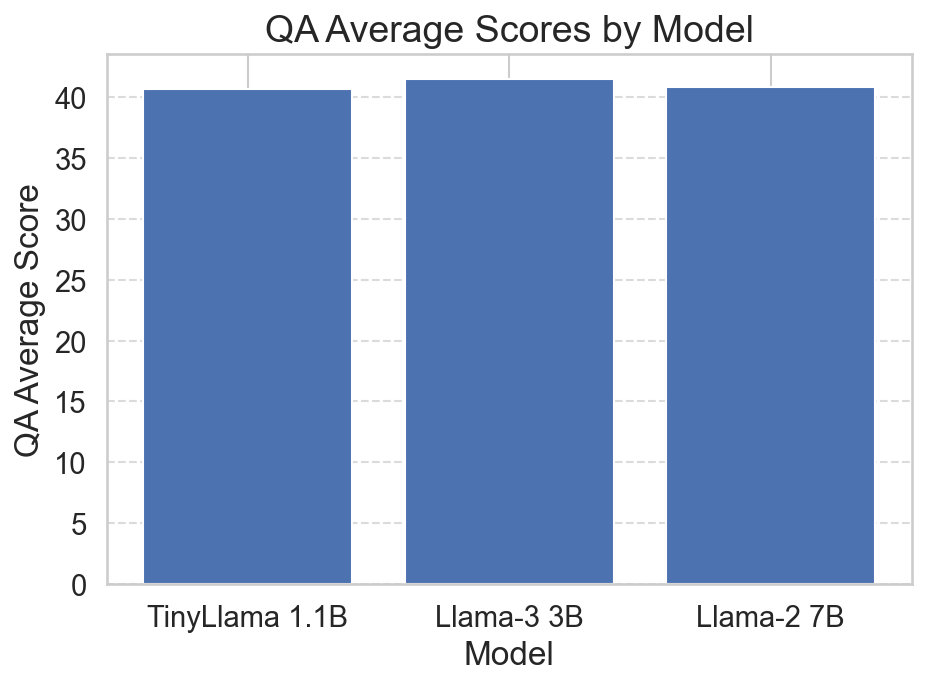

In [30]:
plt.figure()
plt.bar(data_ablate_df['Model'], data_ablate_df['QA Avg'])
plt.xlabel('Model')
plt.ylabel('QA Average Score')
plt.title('QA Average Scores by Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [35]:
size = [32, 64, 128]
PPLs = [2720.33	, 2707.56, 3488.38]
QA_avg = [37.79, 37.23, 37.63]

group_size_df = pd.DataFrame(
    {
        "Group Size": names,
        "PPL": PPLs,
        "QA Avg": QA_avg
    }
)

group_size_df.set_index("Group Size")
print(group_size_df.to_latex())

\begin{tabular}{llrr}
\toprule
 & Group Size & PPL & QA Avg \\
\midrule
0 & TinyLlama 1.1B & 2720.330000 & 37.790000 \\
1 & Llama-3 3B & 2707.560000 & 37.230000 \\
2 & Llama-2 7B & 3488.380000 & 37.630000 \\
\bottomrule
\end{tabular}

